In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, train_test_split

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose


In [13]:
data = pd.read_csv('AirPassengers.csv', header = 0, index_col = 0)

In [ ]:
data.head()

In [9]:
data.describe()

,#Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


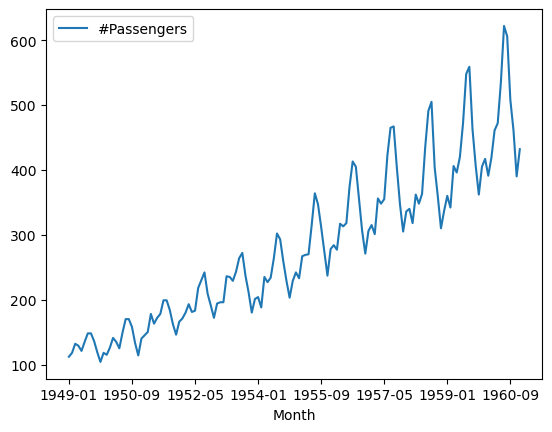

In [10]:
#Q1) Plot raw series — identify trend and seasonality visually
#plt.plot(data['Month'], data['#Passengers'])
data.plot()
plt.show()

In [18]:
X= data.values

In [16]:
#Q2) Run ADF test — is the series stationary? - No looking at the p value, we fail to reject the null hypothesis implying that data has a unit root and
# is non stationary

result = adfuller(X)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
	print('\t%s: %.3f' % (key, value))

ADF Statistic: 0.815369
p-value: 0.991880
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579


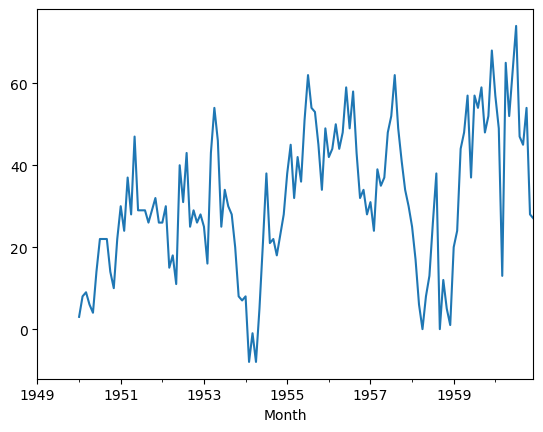

ADF Statistic: -3.375189
p-value: 0.011834
Critical Values:
	1%: -3.482
	5%: -2.884
	10%: -2.579


In [47]:
#Q3) Apply differencing to make it stationary, since p-value <= 0.05 we can reject the null hypotheses and state that data is stationary
data['Differenced'] = data['#Passengers'].diff(12)

data['Differenced'].plot()
plt.show()

X_diff = data['Differenced'].dropna().values
result_diff = adfuller(X_diff[1:])
print('ADF Statistic: %f' % result_diff[0])
print('p-value: %f' % result_diff[1])
print('Critical Values:')
for key, value in result_diff[4].items():
	print('\t%s: %.3f' % (key, value))

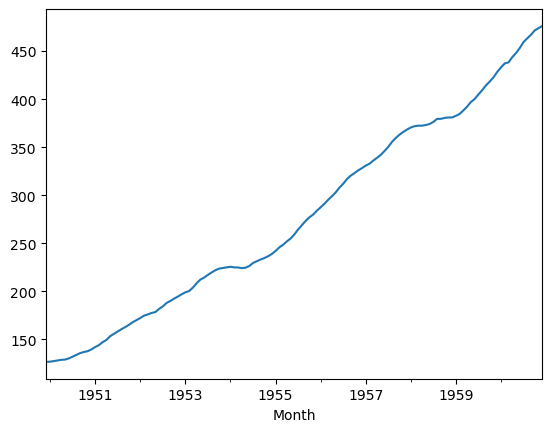

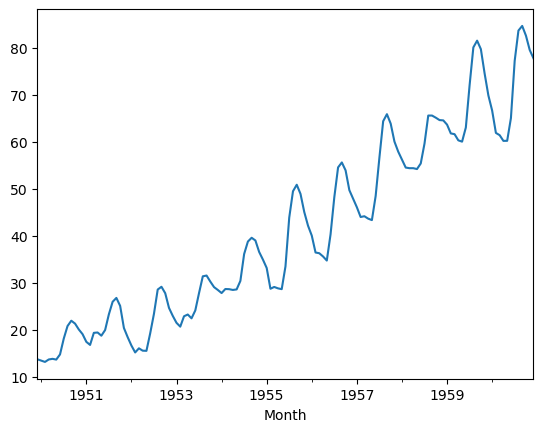

In [48]:
#Q4) Plot rolling mean and rolling standard deviation

data['rolling_mean'] = data['#Passengers'].rolling(window=12).mean()

data['rolling_mean'].dropna().plot()
plt.show()

data['rolling_std'] = data['#Passengers'].rolling(window=12).std()

data['rolling_std'].dropna().plot()
plt.show()

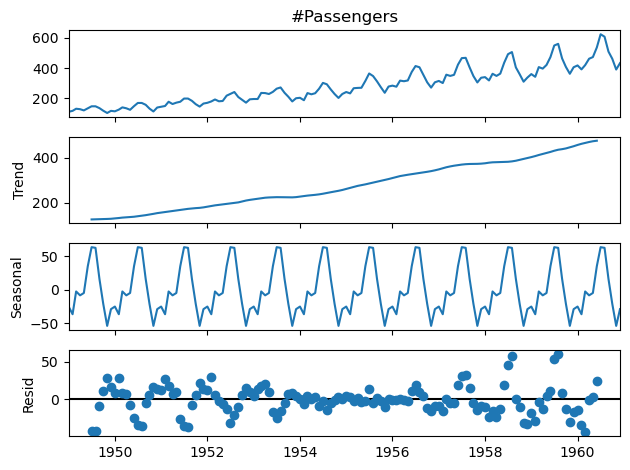

In [50]:
#Q5) Decompose using statsmodels.tsa.seasonal_decompose

data.index = pd.to_datetime(data.index)
result = seasonal_decompose(data['#Passengers'], model='additive', period = 12)
result.plot()
plt.tight_layout()
plt.show()